## 1. Install Required Libraries

In [1]:
# Run only if packages are missing:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn nltk transformers torch wordcloud requests

import os
import re
import requests
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import pipeline
from wordcloud import WordCloud

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Download NLP Resources

In [2]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("NLTK resources are ready.")


NLTK resources are ready.


## 3. Load the Real CSV Dataset


In [3]:
CSV_PATH = "banking_complaints_cfpb_1000.csv"

# Public CSV sample derived from CFPB Consumer Complaint Database.
DATA_URL = (
    "https://huggingface.co/datasets/"
    "claritystorm/cfpb-consumer-complaints/resolve/main/sample_1000.csv"
)

if os.path.exists(CSV_PATH):
    print(f"Using local dataset: {CSV_PATH}")
else:
    print("Local CSV not found. Downloading the real public CSV sample...")
    df_download = pd.read_csv(DATA_URL)
    df_download.to_csv(CSV_PATH, index=False)
    print(f"Downloaded and saved: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH)

print(f"Rows loaded: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")
display(df_raw.head())


Local CSV not found. Downloading the real public CSV sample...
Downloaded and saved: banking_complaints_cfpb_1000.csv
Rows loaded: 1,000
Columns: 22


,date_received,product,sub_product,issue,sub_issue,consumer_narrative,company_public_response,company,state,zip_code,...,submitted_via,date_sent_to_company,company_response,timely_response,consumer_disputed,complaint_id,year,month,has_narrative,product_normalised
0,2023-08-28,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,WI,53143.0,...,Web,2023-08-28,Closed with non-monetary relief,1,NaN,7463130,2023,8,0,Credit reporting or other personal consumer re...
1,2025-03-06,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I have not supplied proof under the doctrine o...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NJ,8046.0,...,Web,2025-03-06,Closed with non-monetary relief,1,NaN,12351479,2025,3,1,Credit reporting or other personal consumer re...
2,2020-04-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",NC,28277.0,...,Web,2020-04-08,Closed with explanation,1,NaN,3598008,2020,4,0,Credit reporting / repair
3,2025-04-25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",SC,29680.0,...,Web,2025-04-25,Closed with non-monetary relief,1,NaN,13183092,2025,4,0,Credit reporting or other personal consumer re...
4,2018-05-16,Debt collection,I do not know,Written notification about debt,Didn't receive enough information to verify debt,NaN,Company has responded to the consumer and the ...,"JH Portfolio Debt Equities, LLC",FL,33901.0,...,Postal mail,2018-05-16,Closed with explanation,1,NaN,2909081,2018,5,0,Debt collection


## 4. Prepare Complaint Dataset

In [4]:
# Standardize the narrative column.
narrative_candidates = [
    "consumer_narrative",
    "consumer_complaint_narrative",
    "narrative"
]

narrative_col = next(
    (c for c in narrative_candidates if c in df_raw.columns),
    None
)

if narrative_col is None:
    raise ValueError(
        "No complaint narrative column was found. "
        "Available columns: " + str(df_raw.columns.tolist())
    )

df = df_raw.copy()

df["narrative"] = df[narrative_col].fillna("").astype(str).str.strip()

# Keep actual complaints with text.
df = df[df["narrative"].str.len() > 20].copy()
df = df.drop_duplicates(subset=["narrative"]).reset_index(drop=True)

print(f"Complaints with usable narratives: {len(df):,}")

print("\nDataset columns:")
print(df.columns.tolist())

display(df[[
    c for c in [
        "complaint_id", "date_received", "product",
        "sub_product", "issue", "sub_issue",
        "company", "submitted_via", "narrative"
    ] if c in df.columns
]].head(10))


Complaints with usable narratives: 266

Dataset columns:
['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'year', 'month', 'has_narrative', 'product_normalised', 'narrative']


,complaint_id,date_received,product,sub_product,issue,sub_issue,company,submitted_via,narrative
0,12351479,2025-03-06,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,I have not supplied proof under the doctrine o...
1,4847443,2021-10-26,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,CAPITAL ONE FINANCIAL CORPORATION,Web,Pursuant to 15 USC 1681a ( 2 ) ( B ) any autho...
2,10459530,2024-10-15,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,I have a goal of getting a house as soon as po...
3,16194215,2025-09-26,Debt collection,Other debt,Written notification about debt,Notification didn't disclose it was an attempt...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,There are collection accounts on my report tha...
4,8976790,2024-05-11,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Experian Information Solutions Inc.,Web,I believe FCRA 605B mandates the removal of an...
5,3549369,2020-02-29,Debt collection,Medical debt,Attempts to collect debt not owed,Debt was result of identity theft,"PlusFour, Inc",Web,PLUS FOUR INC ( XXXX XXXX ) is a result of ide...
6,10944855,2024-11-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,I am greatly concerned about the inclusion of ...
7,4273346,2021-04-05,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Investigation took more than 30 days,"EQUIFAX, INC.",Web,I sent out letters to Equifax in regards to in...
8,12339272,2025-03-06,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was paid,Experian Information Solutions Inc.,Web,Your Account Dispute has been updated. \nThe i...
9,4935585,2021-11-22,Debt collection,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,"Portfolio Recovery Associates, LLC",Web,Portfolio Recovery Associates Inc unlawfully a...


## 5. Dataset Overview

In [5]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

if "product" in df.columns:
    print("\nTop financial products:")
    display(df["product"].value_counts().head(15).rename("complaints"))

if "issue" in df.columns:
    print("\nTop structured complaint issues:")
    display(df["issue"].value_counts().head(20).rename("complaints"))


Dataset shape: (266, 23)

Missing values:


,0
consumer_disputed,252
tags,237
company_public_response,121
zip_code,71
sub_issue,32
sub_product,6
state,2
consumer_narrative,0
issue,0
date_received,0



Top financial products:


,complaints
product,
Credit reporting or other personal consumer reports,101
"Credit reporting, credit repair services, or other personal consumer reports",60
Debt collection,31
Checking or savings account,16
"Money transfer, virtual currency, or money service",11
Mortgage,10
Credit card,10
Credit card or prepaid card,9
Vehicle loan or lease,5



Top structured complaint issues:


,complaints
issue,
Incorrect information on your report,92
Improper use of your report,36
Problem with a credit reporting company's investigation into an existing problem,15
Problem with a company's investigation into an existing problem,15
Attempts to collect debt not owed,10
Written notification about debt,9
Managing an account,9
Getting a credit card,5
Other transaction problem,5


## 6. Financial Product Distribution

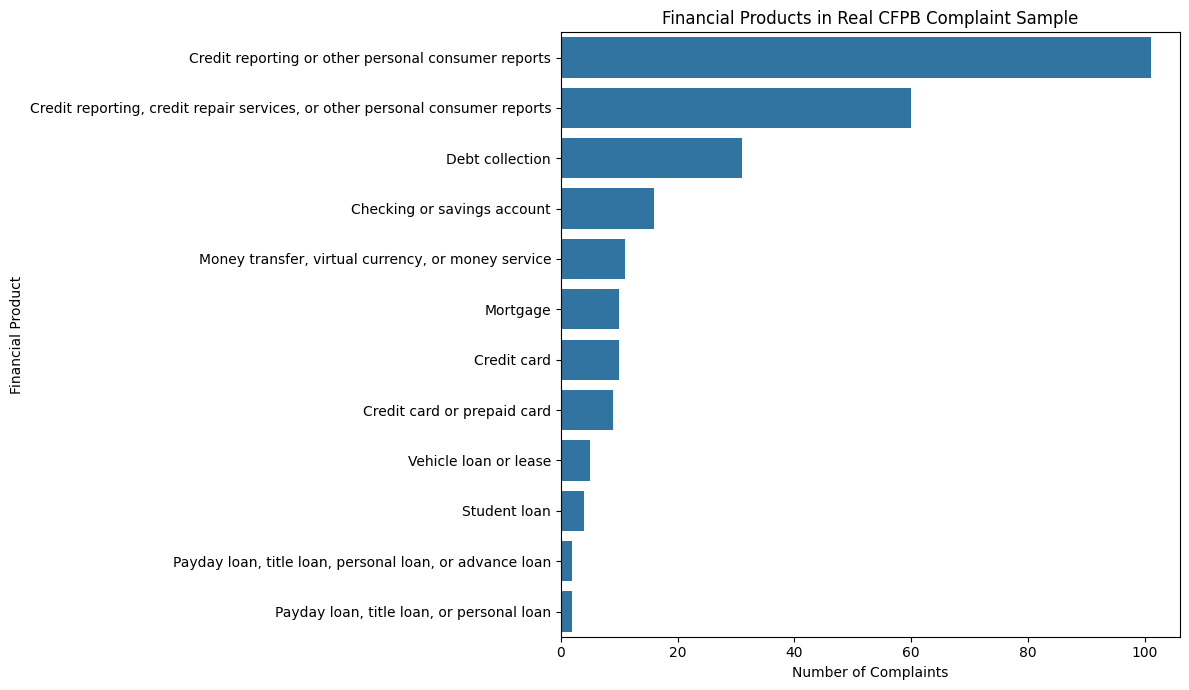

In [6]:
if "product" in df.columns:
    counts = df["product"].value_counts().head(12)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title("Financial Products in Real CFPB Complaint Sample")
    plt.xlabel("Number of Complaints")
    plt.ylabel("Financial Product")
    plt.tight_layout()
    plt.show()


## 7. Frequent Structured Banking Issues

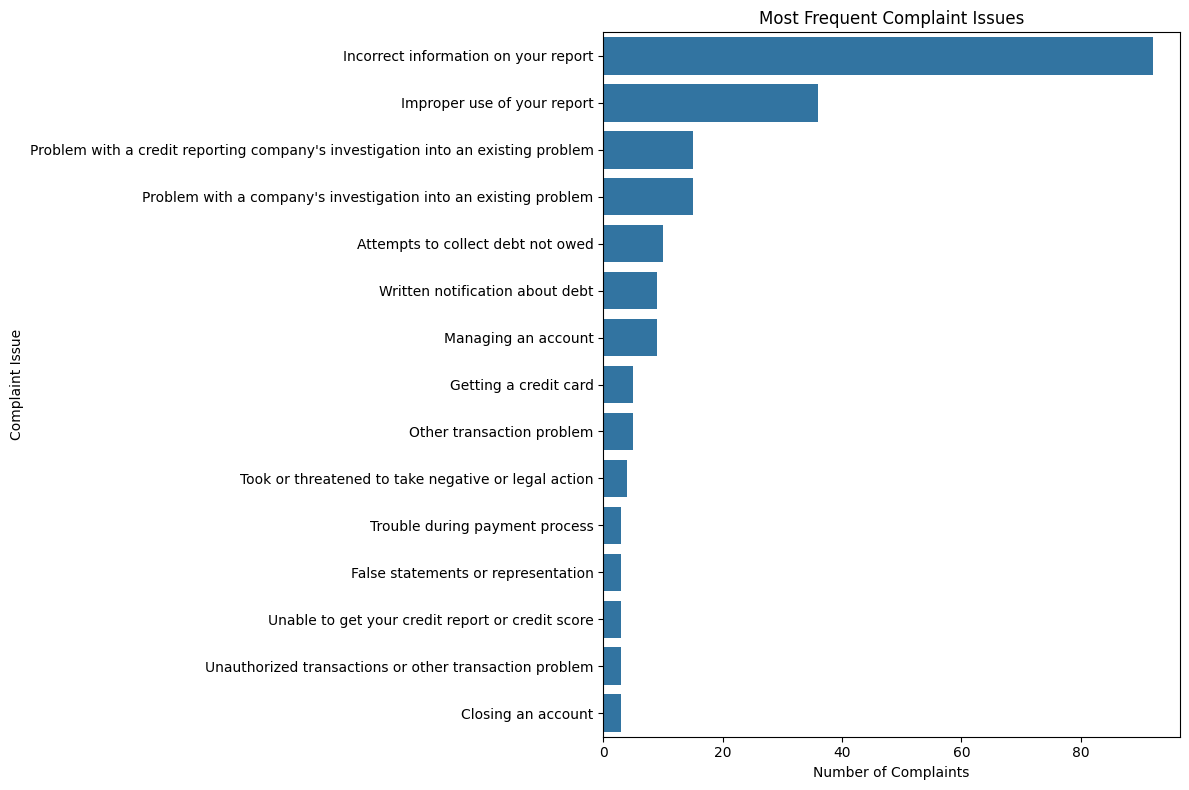

In [7]:
if "issue" in df.columns:
    counts = df["issue"].value_counts().head(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title("Most Frequent Complaint Issues")
    plt.xlabel("Number of Complaints")
    plt.ylabel("Complaint Issue")
    plt.tight_layout()
    plt.show()


## 8. Text Preprocessing

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()

    return " ".join(
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    )

df["clean_narrative"] = df["narrative"].apply(preprocess_text)
df["word_count"] = df["narrative"].str.findall(r"\b\w+\b").str.len()

display(df[["narrative", "clean_narrative"]].head(10))
display(df["word_count"].describe().rename("complaint_word_count"))


,narrative,clean_narrative
0,I have not supplied proof under the doctrine o...,supplied proof doctrine estoppel silence xxxx ...
1,Pursuant to 15 USC 1681a ( 2 ) ( B ) any autho...,pursuant usc authorization approval specific e...
2,I have a goal of getting a house as soon as po...,goal getting house soon possible stuff credit ...
3,There are collection accounts on my report tha...,collection account report believe contain inac...
4,I believe FCRA 605B mandates the removal of an...,believe fcra mandate removal erroneous account...
5,PLUS FOUR INC ( XXXX XXXX ) is a result of ide...,plus four inc xxxx xxxx result identity theft ...
6,I am greatly concerned about the inclusion of ...,greatly concerned inclusion late payment accou...
7,I sent out letters to Equifax in regards to in...,sent letter equifax regard inaccurate account ...
8,Your Account Dispute has been updated. \nThe i...,account dispute updated incorrect account xxxx...
9,Portfolio Recovery Associates Inc unlawfully a...,portfolio recovery associate inc unlawfully ac...


,complaint_word_count
count,266.000000
mean,182.815789
std,323.165989
min,6.000000
25%,52.250000
50%,104.000000
75%,207.500000
max,4466.000000


## 9. Complaint Length Visualization

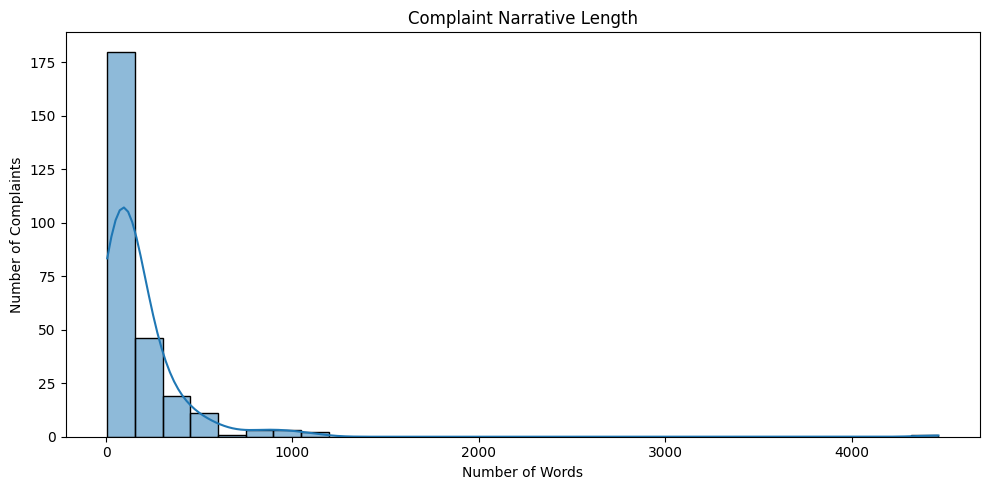

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Complaint Narrative Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()


## 10. Transformer Sentiment Analysis


In [10]:
MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

sentiment_model = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME
)

print("Transformer model loaded successfully.")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Transformer model loaded successfully.


## 11. Perform Sentiment Analysis

In [11]:
results = sentiment_model(
    list(df["narrative"]),
    batch_size=16,
    truncation=True,
    max_length=256
)

df["sentiment"] = [r["label"].title() for r in results]
df["sentiment_confidence"] = [
    round(float(r["score"]), 4) for r in results
]

display(
    df[["narrative", "sentiment", "sentiment_confidence"]].head(10)
)


,narrative,sentiment,sentiment_confidence
0,I have not supplied proof under the doctrine o...,Negative,0.9983
1,Pursuant to 15 USC 1681a ( 2 ) ( B ) any autho...,Negative,0.9981
2,I have a goal of getting a house as soon as po...,Negative,0.9993
3,There are collection accounts on my report tha...,Negative,0.7913
4,I believe FCRA 605B mandates the removal of an...,Negative,0.9997
5,PLUS FOUR INC ( XXXX XXXX ) is a result of ide...,Negative,0.9992
6,I am greatly concerned about the inclusion of ...,Negative,0.9965
7,I sent out letters to Equifax in regards to in...,Negative,0.9883
8,Your Account Dispute has been updated. \nThe i...,Negative,0.9963
9,Portfolio Recovery Associates Inc unlawfully a...,Negative,0.9983


## 12. Sentiment Distribution

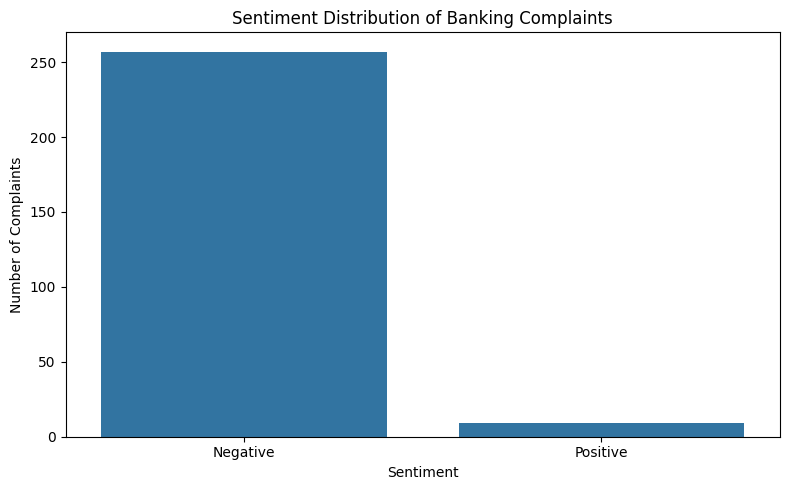

,percentage
sentiment,
Negative,96.62
Positive,3.38


In [12]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution of Banking Complaints")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

display(
    (sentiment_counts / len(df) * 100)
    .round(2)
    .rename("percentage")
)


## 13. TF-IDF Keyword Extraction

,term,tfidf_score
45,xxxx,0.336579
47,xxxx xxxx,0.212075
0,account,0.137272
11,credit,0.126302
34,report,0.105974
22,information,0.079854
12,credit report,0.078085
35,reporting,0.071232
30,payment,0.069774
16,debt,0.057718


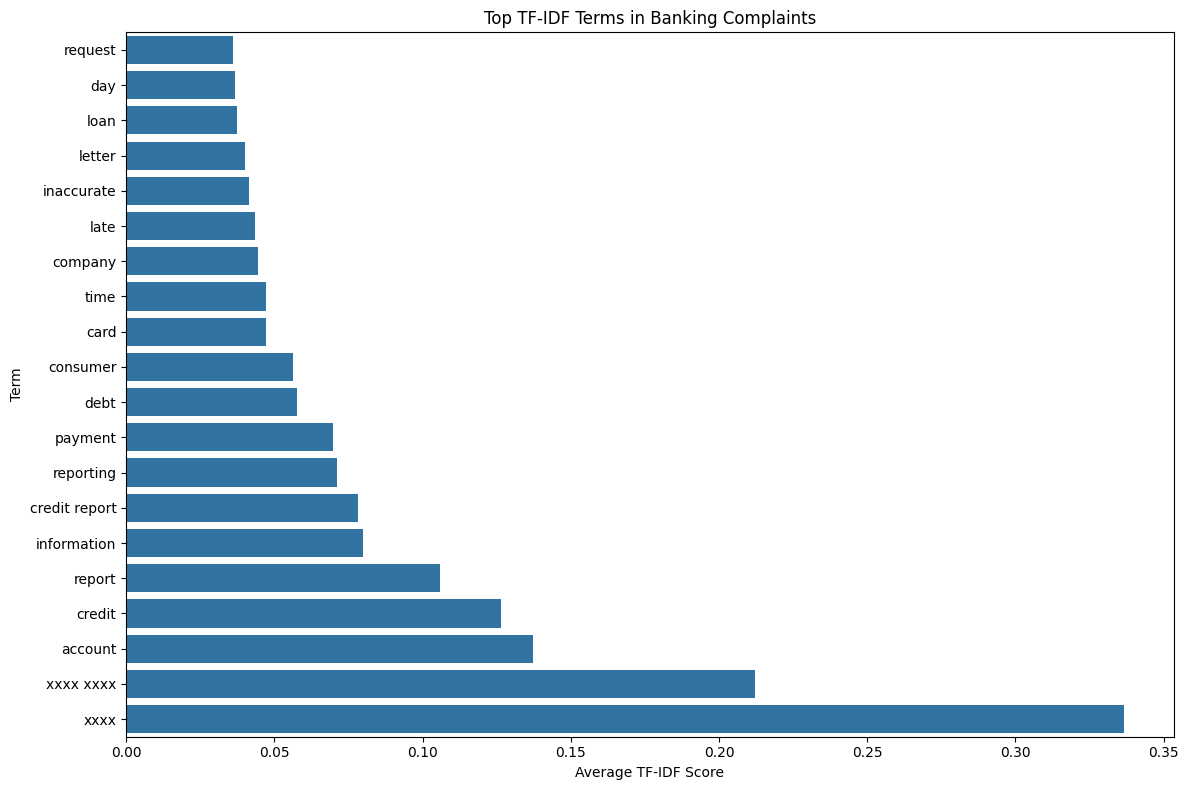

In [13]:
vectorizer = TfidfVectorizer(
    max_features=50,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(df["clean_narrative"])
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_terms = pd.DataFrame({
    "term": vectorizer.get_feature_names_out(),
    "tfidf_score": tfidf_scores
}).sort_values("tfidf_score", ascending=False)

display(tfidf_terms.head(30))

plot_terms = tfidf_terms.head(20).sort_values("tfidf_score")

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_terms, x="tfidf_score", y="term")
plt.title("Top TF-IDF Terms in Banking Complaints")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


## 14. NLP-Based Complaint Categorization

The CFPB already provides structured Product and Issue labels. We retain those official fields and additionally create broader **NLP categories** from the complaint narrative.

Categories:
- Transactions & Payments
- Account Management
- Online / Mobile Banking
- Credit Cards
- Loans & Lending
- Mortgage
- Credit Reporting
- Fraud & Unauthorized Activity
- Fees & Charges
- Customer Service


In [14]:
category_keywords = {
    "Transactions & Payments": [
        "transaction", "payment", "transfer", "wire",
        "deposit", "withdrawal", "cash", "merchant"
    ],
    "Account Management": [
        "account", "balance", "close", "closed",
        "opening", "open", "access", "locked", "freeze", "frozen"
    ],
    "Online / Mobile Banking": [
        "online", "website", "app", "mobile", "login",
        "password", "digital", "internet", "portal"
    ],
    "Credit Cards": [
        "credit card", "card", "cash advance", "billing",
        "statement", "credit limit"
    ],
    "Loans & Lending": [
        "loan", "lender", "lending", "repayment",
        "installment", "interest", "apr", "borrow"
    ],
    "Mortgage": [
        "mortgage", "foreclosure", "home loan",
        "escrow", "property", "servicing"
    ],
    "Credit Reporting": [
        "credit report", "credit bureau", "credit score",
        "reporting", "equifax", "experian", "transunion"
    ],
    "Fraud & Unauthorized Activity": [
        "fraud", "fraudulent", "scam", "identity theft",
        "unauthorized", "stolen", "hack"
    ],
    "Fees & Charges": [
        "fee", "fees", "charge", "charged", "interest",
        "penalty", "overdraft", "cost"
    ],
    "Customer Service": [
        "customer service", "support", "representative",
        "agent", "response", "complaint", "help", "communication"
    ]
}

def detect_categories(text):
    clean = preprocess_text(text)
    found = []

    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if re.search(r"\b" + re.escape(keyword) + r"\b", clean):
                found.append(category)
                break

    return found if found else ["Other"]

df["nlp_categories"] = df["narrative"].apply(detect_categories)

display(
    df[["narrative", "product", "issue", "nlp_categories"]].head(15)
)


,narrative,product,issue,nlp_categories
0,I have not supplied proof under the doctrine o...,Credit reporting or other personal consumer re...,Incorrect information on your report,[Other]
1,Pursuant to 15 USC 1681a ( 2 ) ( B ) any autho...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,"[Transactions & Payments, Credit Cards, Mortga..."
2,I have a goal of getting a house as soon as po...,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,"[Credit Reporting, Customer Service]"
3,There are collection accounts on my report tha...,Debt collection,Written notification about debt,"[Account Management, Credit Reporting]"
4,I believe FCRA 605B mandates the removal of an...,Credit reporting or other personal consumer re...,Incorrect information on your report,"[Account Management, Credit Reporting]"
5,PLUS FOUR INC ( XXXX XXXX ) is a result of ide...,Debt collection,Attempts to collect debt not owed,"[Account Management, Fraud & Unauthorized Acti..."
6,I am greatly concerned about the inclusion of ...,Credit reporting or other personal consumer re...,Incorrect information on your report,"[Transactions & Payments, Account Management]"
7,I sent out letters to Equifax in regards to in...,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,"[Account Management, Credit Reporting]"
8,Your Account Dispute has been updated. \nThe i...,Debt collection,Attempts to collect debt not owed,"[Account Management, Credit Reporting]"
9,Portfolio Recovery Associates Inc unlawfully a...,Debt collection,Threatened to contact someone or share informa...,"[Credit Reporting, Fraud & Unauthorized Activi..."


## 15. Common NLP Complaint Categories

,category,mentions
0,Account Management,174
1,Credit Reporting,160
2,Customer Service,91
3,Transactions & Payments,88
4,Fraud & Unauthorized Activity,68
5,Credit Cards,54
6,Fees & Charges,37
7,Loans & Lending,34
8,Mortgage,18
9,Online / Mobile Banking,18


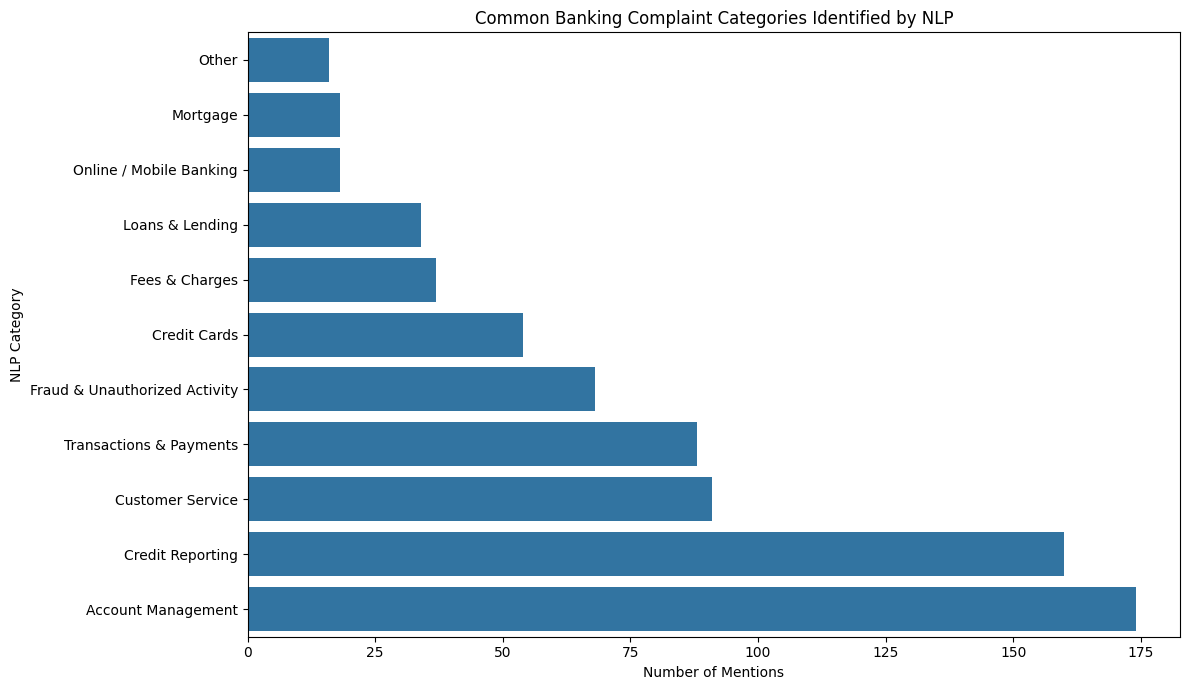

In [15]:
category_rows = []

for _, row in df.iterrows():
    for category in row["nlp_categories"]:
        category_rows.append({
            "category": category,
            "sentiment": row["sentiment"],
            "narrative": row["narrative"],
            "issue": row["issue"] if "issue" in df.columns else ""
        })

category_df = pd.DataFrame(category_rows)

category_counts = (
    category_df["category"]
    .value_counts()
    .reset_index()
)
category_counts.columns = ["category", "mentions"]

display(category_counts)

plt.figure(figsize=(12, 7))
plot_data = category_counts.sort_values("mentions")
sns.barplot(data=plot_data, x="mentions", y="category")
plt.title("Common Banking Complaint Categories Identified by NLP")
plt.xlabel("Number of Mentions")
plt.ylabel("NLP Category")
plt.tight_layout()
plt.show()


## 16. Category-wise Sentiment

sentiment,Positive,Neutral,Negative
category,,,
Account Management,4,0,170
Credit Cards,0,0,54
Credit Reporting,6,0,154
Customer Service,1,0,90
Fees & Charges,1,0,36
Fraud & Unauthorized Activity,1,0,67
Loans & Lending,0,0,34
Mortgage,1,0,17
Online / Mobile Banking,0,0,18


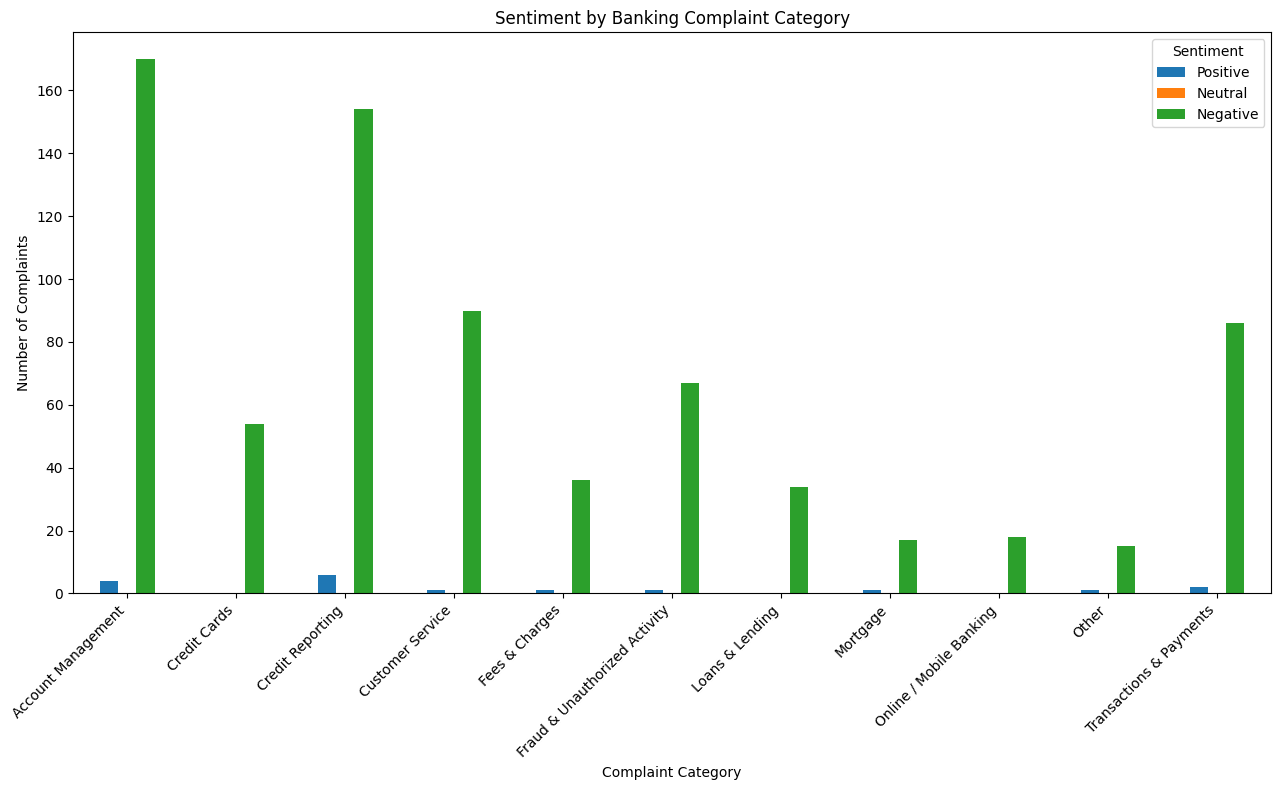

In [16]:
category_sentiment = pd.crosstab(
    category_df["category"],
    category_df["sentiment"]
)

for col in ["Positive", "Neutral", "Negative"]:
    if col not in category_sentiment.columns:
        category_sentiment[col] = 0

category_sentiment = category_sentiment[
    ["Positive", "Neutral", "Negative"]
]

display(category_sentiment)

category_sentiment.plot(
    kind="bar",
    figsize=(13, 8)
)

plt.title("Sentiment by Banking Complaint Category")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


## 17. Identify Frequent Banking Issues

In [17]:
if "issue" in df.columns:
    issue_summary = df.groupby("issue").agg(
        complaint_count=("issue", "size"),
        negative_complaints=(
            "sentiment",
            lambda x: (x == "Negative").sum()
        )
    ).reset_index()

    issue_summary["negative_rate"] = (
        issue_summary["negative_complaints"] /
        issue_summary["complaint_count"] * 100
    ).round(2)

    # Priority combines negative volume and negative rate.
    issue_summary["priority_score"] = (
        issue_summary["negative_complaints"] * 0.7 +
        issue_summary["negative_rate"] * 0.3
    ).round(2)

    frequent_issues = issue_summary.sort_values(
        "complaint_count",
        ascending=False
    )

    display(frequent_issues.head(20))


,issue,complaint_count,negative_complaints,negative_rate,priority_score
24,Incorrect information on your report,92,88,95.65,90.29
22,Improper use of your report,36,36,100.00,55.20
34,Problem with a company's investigation into an...,15,15,100.00,40.50
35,Problem with a credit reporting company's inve...,15,14,93.33,37.80
2,Attempts to collect debt not owed,10,9,90.00,33.30
26,Managing an account,9,9,100.00,36.30
51,Written notification about debt,9,8,88.89,32.27
31,Other transaction problem,5,5,100.00,33.50
19,Getting a credit card,5,5,100.00,33.50
43,Took or threatened to take negative or legal a...,4,4,100.00,32.80


## 18. High-Priority Banking Issues

,issue,complaint_count,negative_complaints,negative_rate,priority_score
24,Incorrect information on your report,92,88,95.65,90.29
22,Improper use of your report,36,36,100.00,55.20
34,Problem with a company's investigation into an...,15,15,100.00,40.50
35,Problem with a credit reporting company's inve...,15,14,93.33,37.80
26,Managing an account,9,9,100.00,36.30
19,Getting a credit card,5,5,100.00,33.50
31,Other transaction problem,5,5,100.00,33.50
2,Attempts to collect debt not owed,10,9,90.00,33.30
43,Took or threatened to take negative or legal a...,4,4,100.00,32.80
51,Written notification about debt,9,8,88.89,32.27


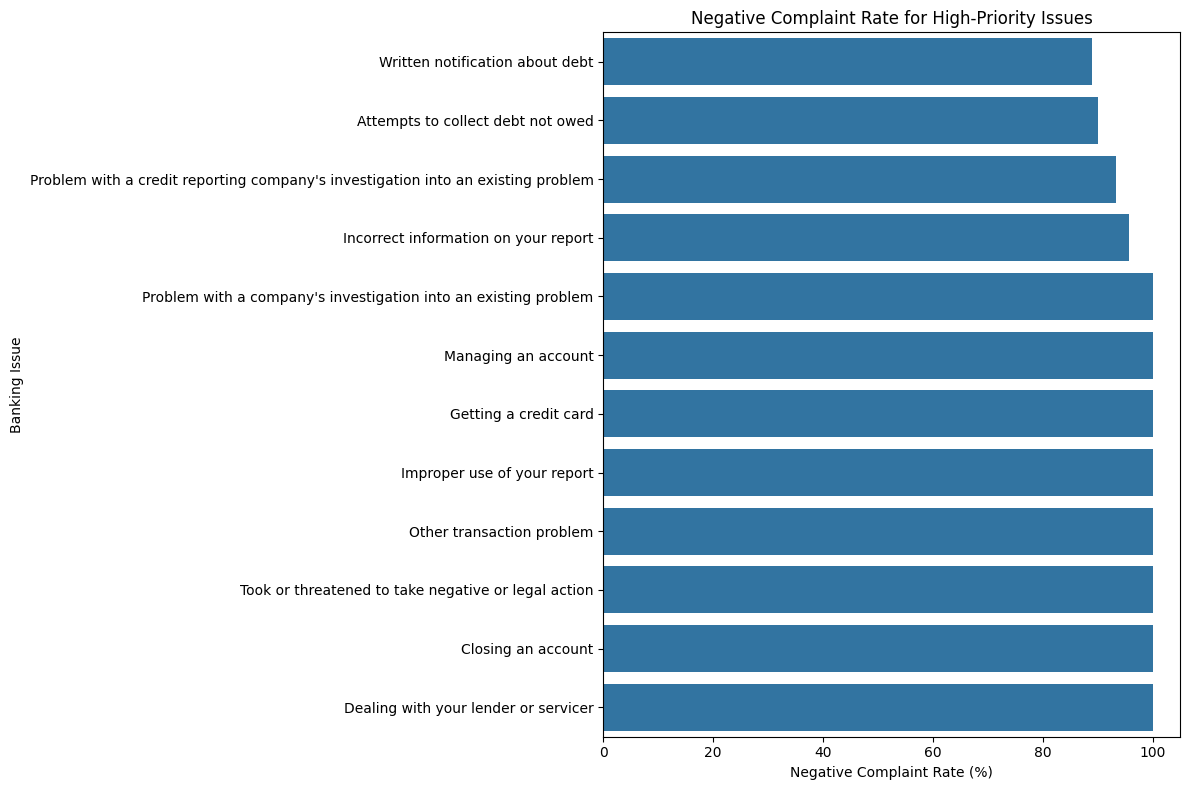

In [18]:
if "issue" in df.columns:
    priority_issues = issue_summary[
        issue_summary["negative_complaints"] > 0
    ].sort_values(
        ["priority_score", "complaint_count"],
        ascending=False
    )

    display(priority_issues.head(15))

    plot_priority = priority_issues.head(12).sort_values("negative_rate")

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=plot_priority,
        x="negative_rate",
        y="issue"
    )
    plt.title("Negative Complaint Rate for High-Priority Issues")
    plt.xlabel("Negative Complaint Rate (%)")
    plt.ylabel("Banking Issue")
    plt.tight_layout()
    plt.show()


## 19. Negative Complaint Word Cloud

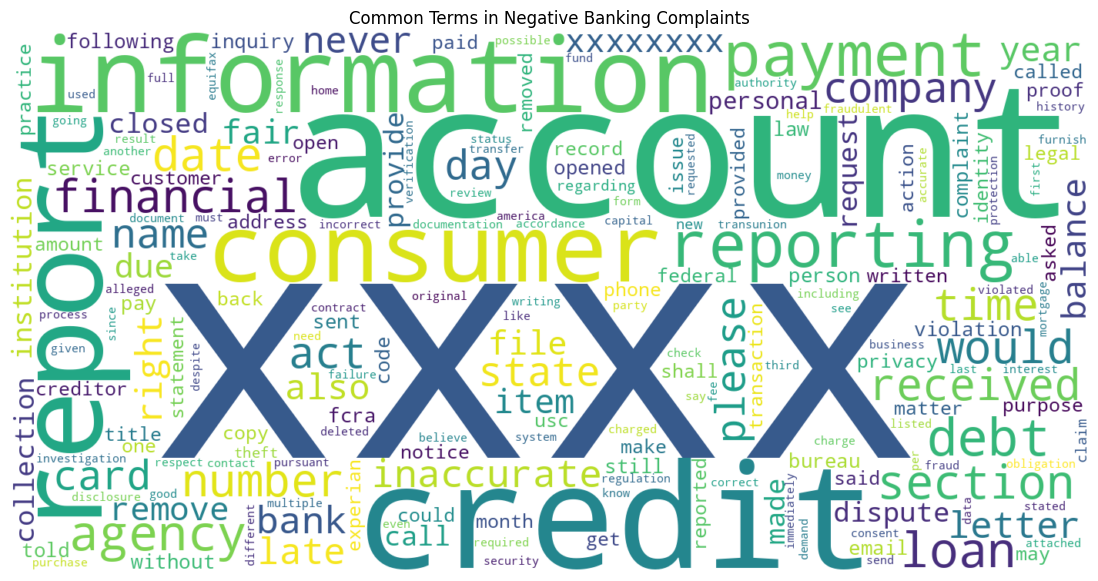

In [19]:
negative_text = " ".join(
    df.loc[df["sentiment"] == "Negative", "clean_narrative"]
)

if negative_text.strip():
    wordcloud = WordCloud(
        width=1400,
        height=700,
        background_color="white",
        stopwords=stop_words,
        collocations=False
    ).generate(negative_text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Common Terms in Negative Banking Complaints")
    plt.show()


## 20. Representative Complaints

In [20]:
if "issue" in df.columns:
    for issue in priority_issues.head(7)["issue"]:
        examples = df[
            (df["issue"] == issue) &
            (df["sentiment"] == "Negative")
        ]["narrative"].drop_duplicates().head(3).tolist()

        print("\n" + "=" * 85)
        print(issue.upper())
        print("=" * 85)

        if examples:
            for i, example in enumerate(examples, 1):
                short = example[:700]
                suffix = "..." if len(example) > 700 else ""
                print(f"{i}. {short}{suffix}")
        else:
            print("No negative examples available.")



INCORRECT INFORMATION ON YOUR REPORT
1. I have not supplied proof under the doctrine of estoppel by silence, XXXX XXXX XXXXXXXX XXXX XXXX XXXX  XXXX XXXX XXXX. I pressume that no proof of the alleged debt, nor therefore any such debt, in fact therefore exist.
2. Pursuant to 15 USC 1681a ( 2 ) ( B ) any authorization or approval of a specific extension of credit directly or indirectly by the issuer of a credit card or similar device ; Should be excluded from a consumer report. The definition of a credit card under 15 USC 1681 is the same as it is under 15 USC 1602 ( l ) which is the term credit card means any card, plate, coupon, book or other credits device existing for the purpose of obtaining, money, property, labor, or services on credit Notice, congress said ANY card. The credit card is my social security card. This is the credit card I used to originate every consumer credit transaction. 

I, XXXX XXXX, never granted XXXX, XXXX, or XXXX written...
3. I believe FCRA 605B mandates 

## 21. Automated Business Recommendations

In [21]:
recommendations = {
    "Transactions & Payments":
        "Strengthen transaction monitoring, payment tracking, and dispute resolution.",
    "Account Management":
        "Simplify account access, closure, and account-service workflows.",
    "Online / Mobile Banking":
        "Improve login reliability, mobile usability, error messages, and self-service support.",
    "Credit Cards":
        "Improve billing clarity, payment processing, dispute handling, and card communication.",
    "Loans & Lending":
        "Provide clearer loan terms, repayment information, interest explanations, and status updates.",
    "Mortgage":
        "Improve servicing communication, payment processing, escrow information, and escalation.",
    "Credit Reporting":
        "Strengthen credit-information accuracy checks and dispute-correction workflows.",
    "Fraud & Unauthorized Activity":
        "Improve fraud detection, rapid blocking, customer alerts, and recovery processes.",
    "Fees & Charges":
        "Make fees and interest charges transparent and clearly explain them before charging.",
    "Customer Service":
        "Reduce response times, improve first-contact resolution, and strengthen escalation."
}

print("=" * 90)
print("BANKING COMPLAINT ANALYTICAL REPORT")
print("=" * 90)

print(f"Total complaints in real CSV sample: {len(df):,}")

print("\nTop financial products:")
if "product" in df.columns:
    for i, (name, count) in enumerate(
        df["product"].value_counts().head(10).items(), 1
    ):
        print(f"{i}. {name}: {count:,}")

print("\nTop structured complaint issues:")
if "issue" in df.columns:
    for i, (name, count) in enumerate(
        df["issue"].value_counts().head(10).items(), 1
    ):
        print(f"{i}. {name}: {count:,}")

print("\nTop NLP categories:")
for i, row in enumerate(category_counts.head(10).itertuples(), 1):
    print(f"{i}. {row.category}: {row.mentions:,}")

print("\nPriority issues:")
if "issue" in df.columns:
    for i, row in enumerate(priority_issues.head(7).itertuples(), 1):
        print(
            f"{i}. {row.issue}: "
            f"{row.complaint_count:,} complaints; "
            f"{row.negative_rate:.1f}% negative"
        )

print("\nRecommended actions:")
present_categories = set(category_counts["category"])

for category, recommendation in recommendations.items():
    if category in present_categories:
        print(f"• {category}: {recommendation}")

print("=" * 90)


BANKING COMPLAINT ANALYTICAL REPORT
Total complaints in real CSV sample: 266

Top financial products:
1. Credit reporting or other personal consumer reports: 101
2. Credit reporting, credit repair services, or other personal consumer reports: 60
3. Debt collection: 31
4. Checking or savings account: 16
5. Money transfer, virtual currency, or money service: 11
6. Mortgage: 10
7. Credit card: 10
8. Credit card or prepaid card: 9
9. Vehicle loan or lease: 5
10. Student loan: 4

Top structured complaint issues:
1. Incorrect information on your report: 92
2. Improper use of your report: 36
3. Problem with a credit reporting company's investigation into an existing problem: 15
4. Problem with a company's investigation into an existing problem: 15
5. Attempts to collect debt not owed: 10
6. Written notification about debt: 9
7. Managing an account: 9
8. Getting a credit card: 5
9. Other transaction problem: 5
10. Took or threatened to take negative or legal action: 4

Top NLP categories:
1. A

## 22. Save Final Analytical Dataset

In [22]:
final_columns = [
    "complaint_id",
    "date_received",
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "submitted_via",
    "company_response",
    "timely_response",
    "narrative",
    "clean_narrative",
    "sentiment",
    "sentiment_confidence",
    "nlp_categories"
]

available_columns = [c for c in final_columns if c in df.columns]
final_df = df[available_columns].copy()

final_df["nlp_categories"] = final_df["nlp_categories"].apply(
    lambda x: "; ".join(x) if isinstance(x, list) else str(x)
)

final_df.to_csv(
    "banking_complaint_analysis_results.csv",
    index=False
)

display(final_df.head(20))
print("Saved: banking_complaint_analysis_results.csv")


,complaint_id,date_received,product,sub_product,issue,sub_issue,company,submitted_via,company_response,timely_response,narrative,clean_narrative,sentiment,sentiment_confidence,nlp_categories
0,12351479,2025-03-06,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,Closed with non-monetary relief,1,I have not supplied proof under the doctrine o...,supplied proof doctrine estoppel silence xxxx ...,Negative,0.9983,Other
1,4847443,2021-10-26,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,CAPITAL ONE FINANCIAL CORPORATION,Web,Closed with explanation,1,Pursuant to 15 USC 1681a ( 2 ) ( B ) any autho...,pursuant usc authorization approval specific e...,Negative,0.9981,Transactions & Payments; Credit Cards; Mortgag...
2,10459530,2024-10-15,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,Closed with non-monetary relief,1,I have a goal of getting a house as soon as po...,goal getting house soon possible stuff credit ...,Negative,0.9993,Credit Reporting; Customer Service
3,16194215,2025-09-26,Debt collection,Other debt,Written notification about debt,Notification didn't disclose it was an attempt...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,Closed with explanation,1,There are collection accounts on my report tha...,collection account report believe contain inac...,Negative,0.7913,Account Management; Credit Reporting
4,8976790,2024-05-11,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Experian Information Solutions Inc.,Web,Closed with explanation,1,I believe FCRA 605B mandates the removal of an...,believe fcra mandate removal erroneous account...,Negative,0.9997,Account Management; Credit Reporting
5,3549369,2020-02-29,Debt collection,Medical debt,Attempts to collect debt not owed,Debt was result of identity theft,"PlusFour, Inc",Web,Closed with explanation,1,PLUS FOUR INC ( XXXX XXXX ) is a result of ide...,plus four inc xxxx xxxx result identity theft ...,Negative,0.9992,Account Management; Fraud & Unauthorized Activ...
6,10944855,2024-11-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Web,Closed with non-monetary relief,1,I am greatly concerned about the inclusion of ...,greatly concerned inclusion late payment accou...,Negative,0.9965,Transactions & Payments; Account Management
7,4273346,2021-04-05,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Investigation took more than 30 days,"EQUIFAX, INC.",Web,Closed with explanation,1,I sent out letters to Equifax in regards to in...,sent letter equifax regard inaccurate account ...,Negative,0.9883,Account Management; Credit Reporting
8,12339272,2025-03-06,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was paid,Experian Information Solutions Inc.,Web,Closed with explanation,1,Your Account Dispute has been updated. \nThe i...,account dispute updated incorrect account xxxx...,Negative,0.9963,Account Management; Credit Reporting
9,4935585,2021-11-22,Debt collection,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,"Portfolio Recovery Associates, LLC",Web,Closed with explanation,1,Portfolio Recovery Associates Inc unlawfully a...,portfolio recovery associate inc unlawfully ac...,Negative,0.9983,Credit Reporting; Fraud & Unauthorized Activit...


Saved: banking_complaint_analysis_results.csv
